In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('titanic.csv')
df.head()

Saving titanic.csv to titanic.csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Data Cleaning

In [5]:
print("Missing values:\n", df.isnull().sum())

# Fill missing Age with median
df['age'].fillna(df['age'].median(), inplace=True)

# Drop Cabin column (too many missing values)
if 'cabin' in df.columns:
    df.drop(columns=['cabin'], inplace=True)

# Fill Embarked with mode
if 'embarked' in df.columns:
    df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

print("\nAfter cleaning:\n", df.isnull().sum())

Missing values:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

After cleaning:
 survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


/tmp/ipykernel_12268/2506744977.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_12268/2506744977.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

Who survived more Male vs Female?

In [6]:
gender_survival = df.groupby('sex')['survived'].mean()

print("Survival Rate by Gender:\n", gender_survival)

Survival Rate by Gender:
 sex
female    0.742038
male      0.188908
Name: survived, dtype: float64


Did passenger class affect survival?

In [7]:
class_survival = df.groupby('pclass')['survived'].mean()

print("Survival Rate by Class:\n", class_survival)

Survival Rate by Class:
 pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


Survival Rate by Age Group?

In [8]:
# Create age groups
bins = [0, 12, 20, 40, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Mid-age', 'Senior']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

age_survival = df.groupby('age_group')['survived'].mean()
print("Survival Rate by Age Group:\n", age_survival)

Survival Rate by Age Group:
 age_group
Child      0.579710
Teen       0.381818
Adult      0.364769
Mid-age    0.390625
Senior     0.227273
Name: survived, dtype: float64


/tmp/ipykernel_12268/3761211829.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby('age_group')['survived'].mean()


📊 📈 **Visualizations**

Survival by Gender


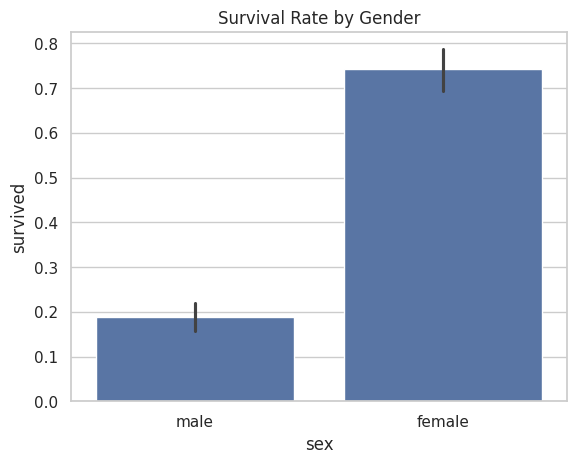

In [9]:
sns.barplot(x='sex', y='survived', data=df)
plt.title("Survival Rate by Gender")
plt.show()

Survival by Class

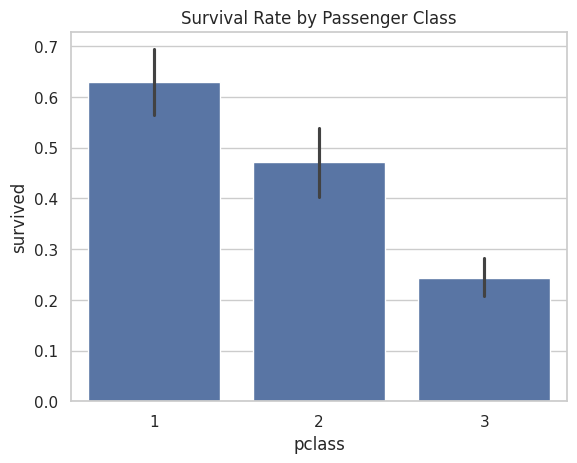

In [10]:
sns.barplot(x='pclass', y='survived', data=df)
plt.title("Survival Rate by Passenger Class")
plt.show()

Age Distribution

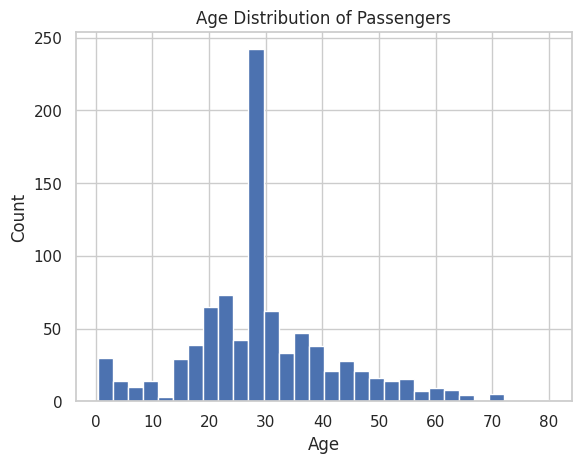

In [11]:
plt.hist(df['age'], bins=30)
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()